In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import plot_model_comparison

import copy


# params_to_latex(par)

## Increase chance of being reassigned

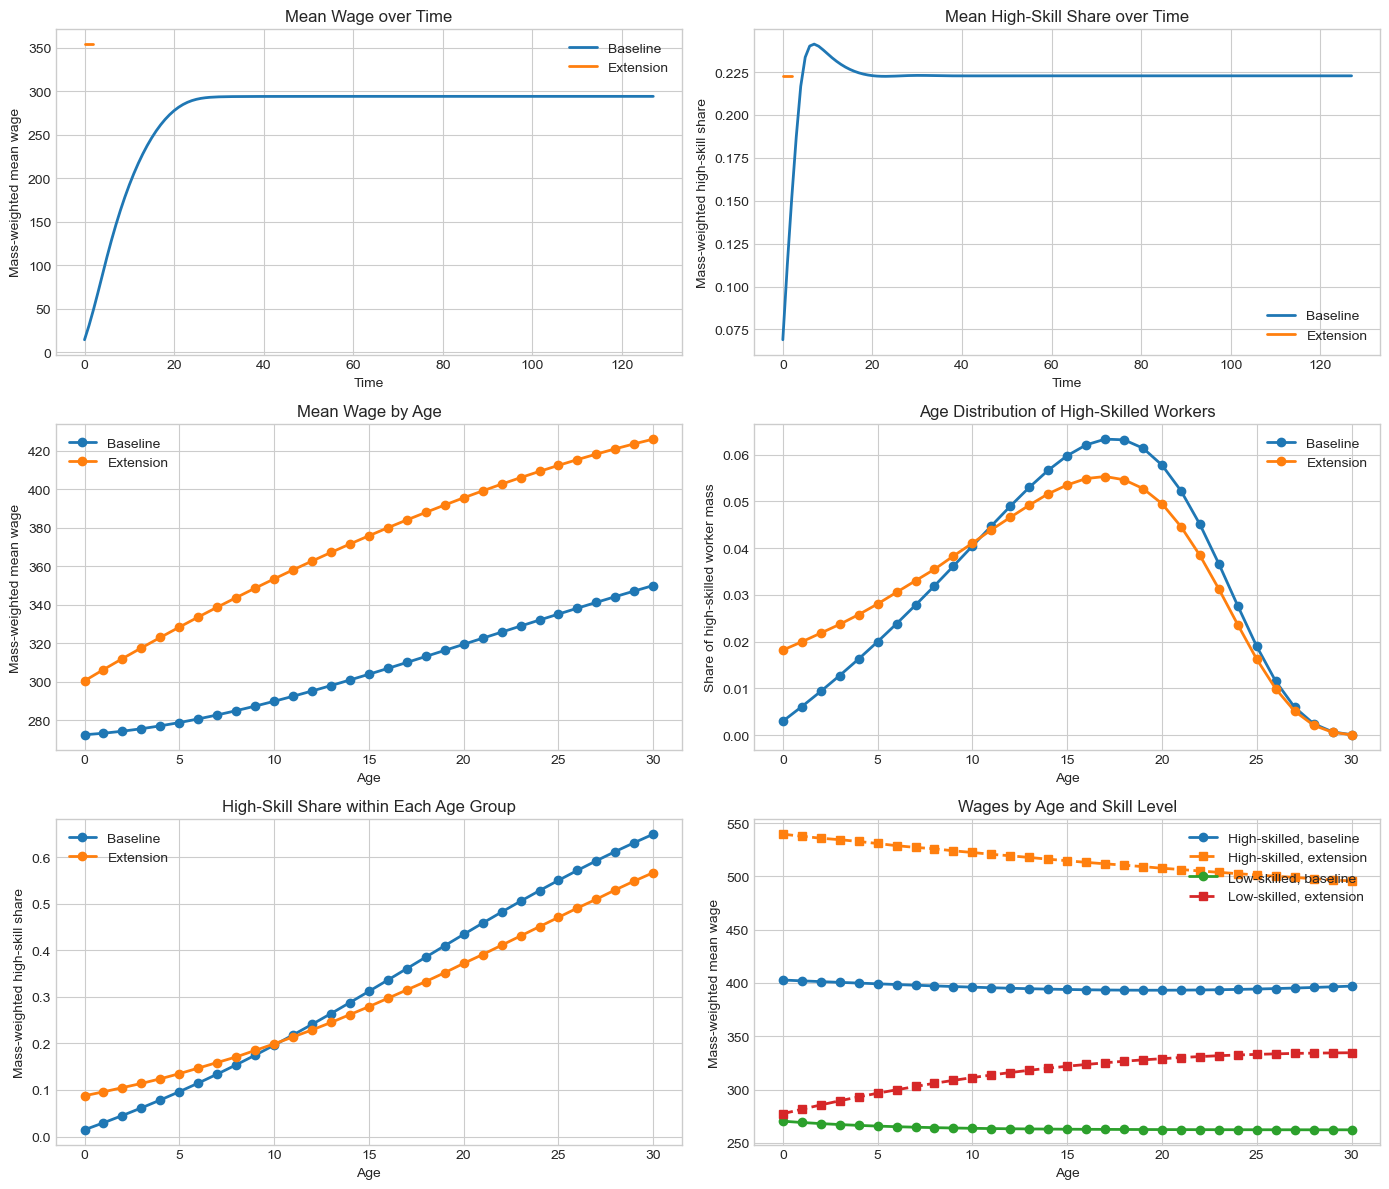

In [2]:
# Baseline
model = ModelClass()

par = model.par
sim = model.sim

model.solve(do_print=False)
model_baseline = copy.deepcopy(model)

# Extension
model.par.reassigned_percentage = 1.0  # Percentage of high-skilled labor that can be fired each period
model.allocate()
model.solve(do_print=False)
model_extension = copy.deepcopy(model)

plot_model_comparison(model_baseline, model_extension)

## Increase the number of agents in the model

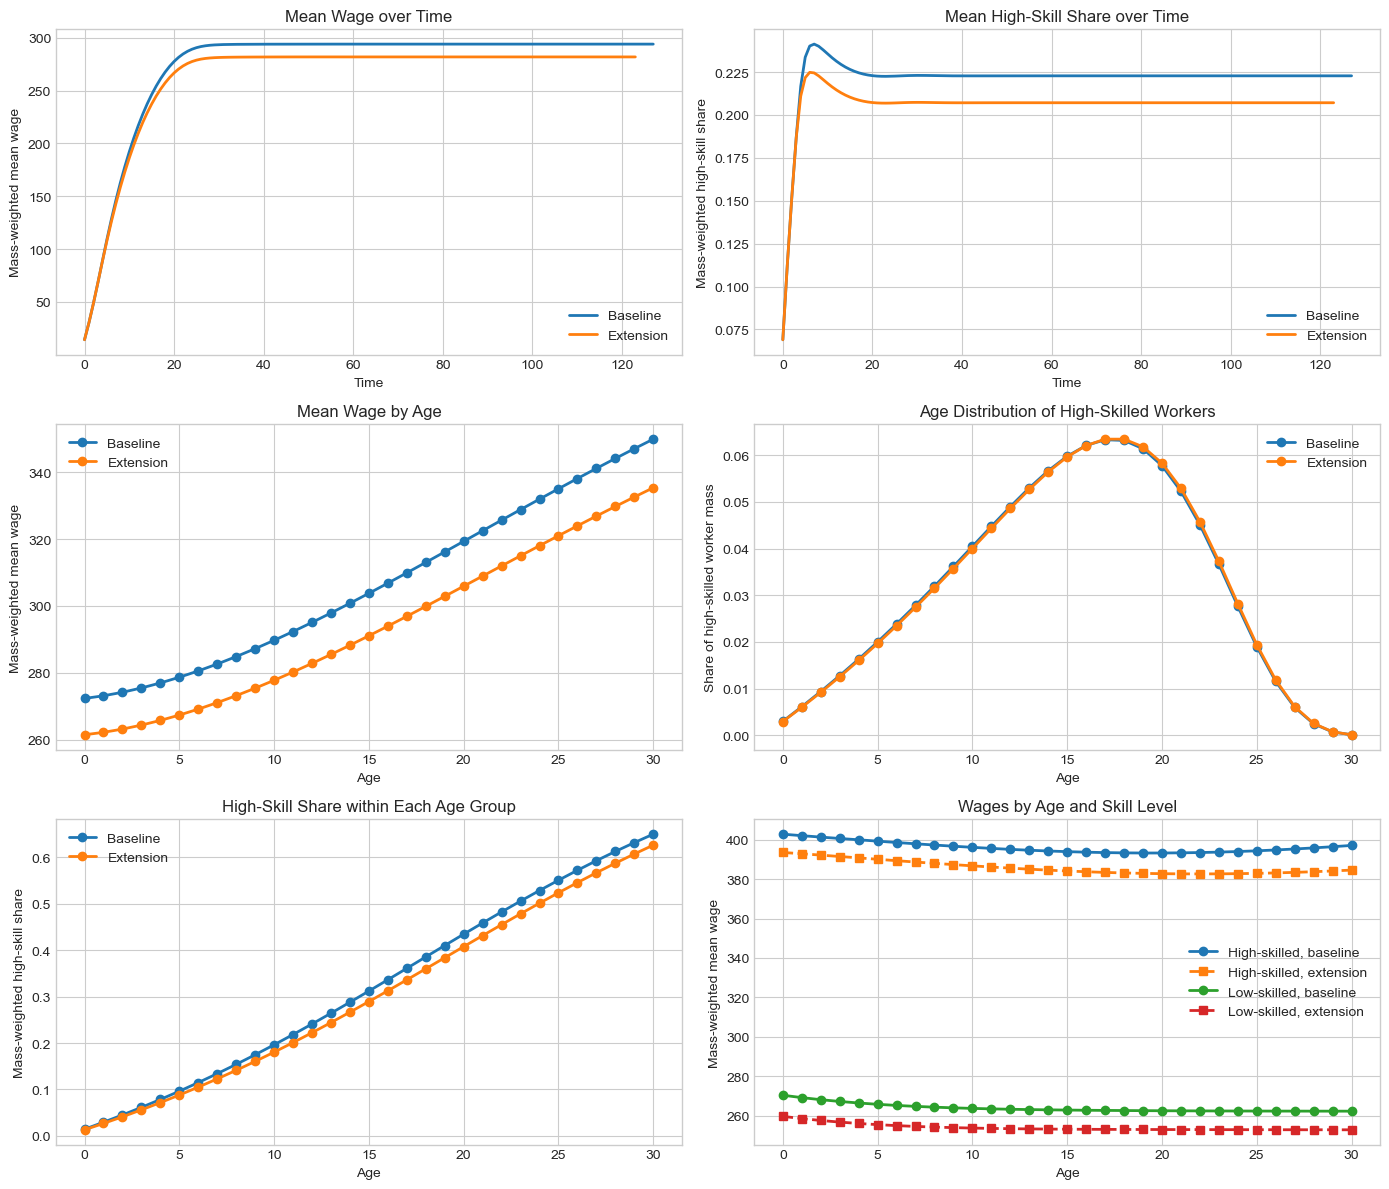

In [3]:
# Baseline
model = ModelClass()

par = model.par
sim = model.sim

model.solve(do_print=False)
model_baseline = copy.deepcopy(model)

# Extension
model.par.N_1 = int(model.par.N_1 * 1.2)
model.allocate()
model.solve(do_print=False)
model_extension = copy.deepcopy(model)

plot_model_comparison(model_baseline, model_extension)

## Decrease the retirement rate, such that people stay in the labor market for longer

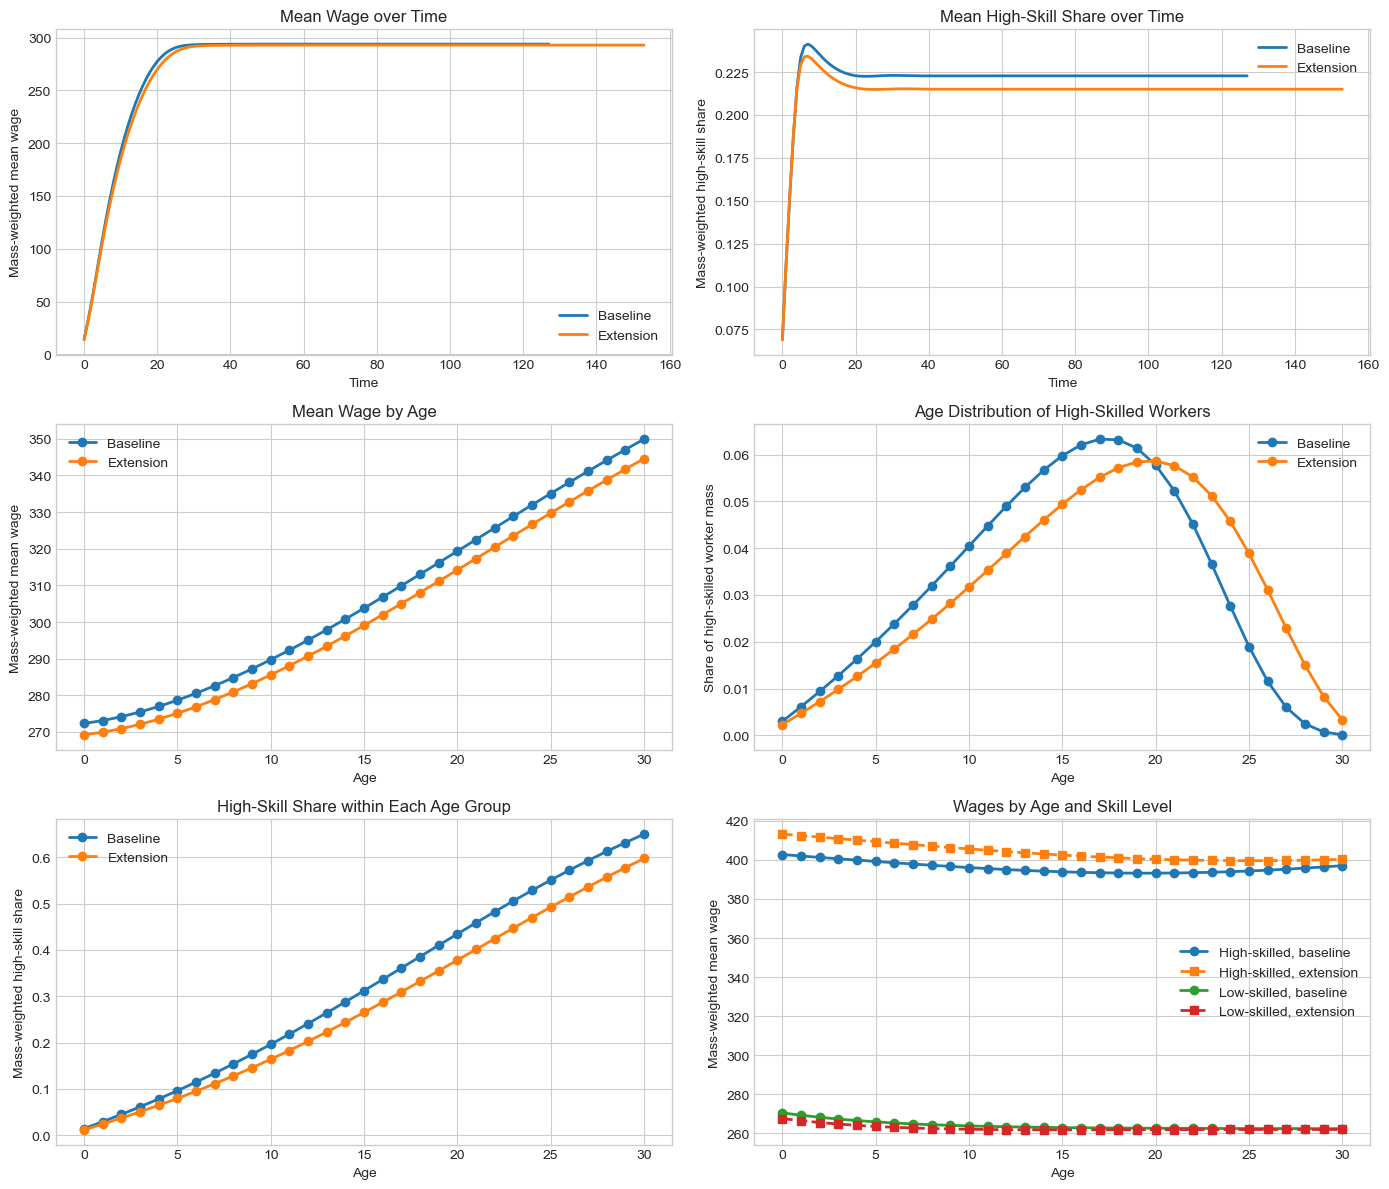

In [4]:
model = ModelClass()

par = model.par
sim = model.sim

# Baseline
model.solve(do_print=False)
model_baseline = copy.deepcopy(model)

# Extension
model.par.rho = model.par.rho ** 0.5
model.allocate()
model.solve(do_print=False)
model_extension = copy.deepcopy(model)

plot_model_comparison(model_baseline, model_extension)

The firm has a larger pool of older workers, and can hence hire individuals with more human capital. They therefore need to hire fewer high level workers.

- Check the mechanics
- Firm revenue
- Compensation of workers

## Increase productivity

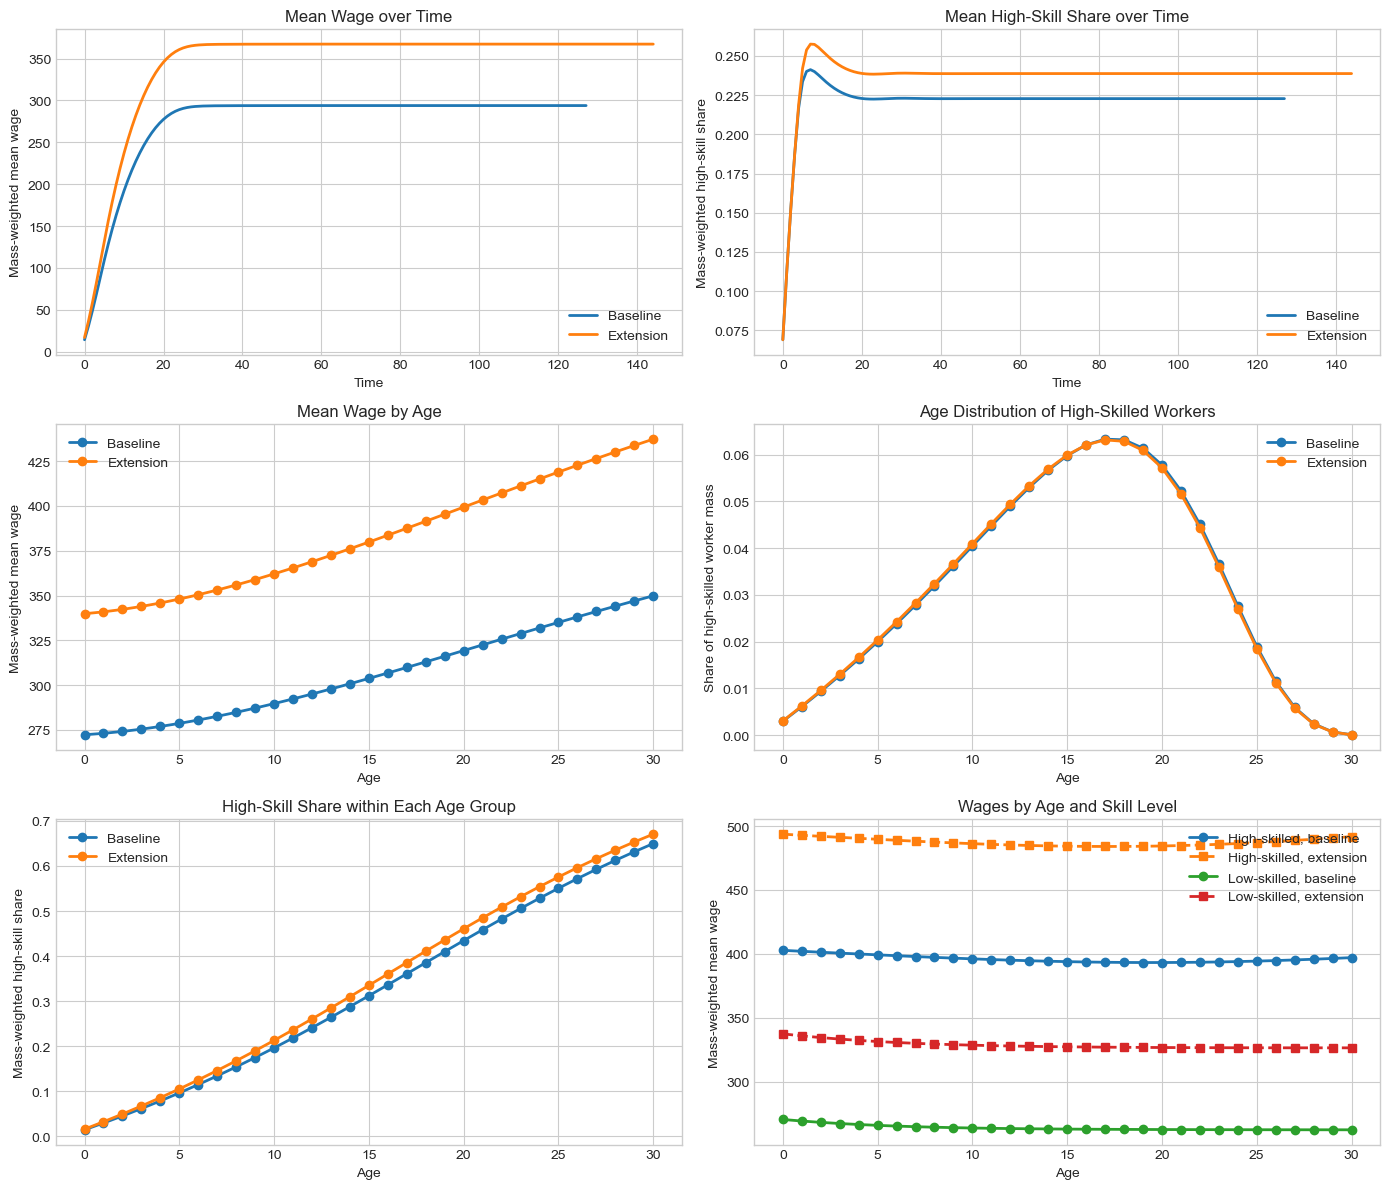

In [5]:
model = ModelClass()

par = model.par
sim = model.sim

# Baseline
model.solve(do_print=False)
model_baseline = copy.deepcopy(model)

# Extension
# model.par.rho = model.par.rho ** 0.5
model.par.A = model.par.A * 1.2
model.allocate()
model.solve(do_print=False)
model_extension = copy.deepcopy(model)

plot_model_comparison(model_baseline, model_extension)

Debugging

In [6]:
for age in range(31):
    mask = (
        (model_baseline.sol.age[:, 31] == age) &
        (model_baseline.sol.l_h[:, 31] == 1)
    )
    mean = model_baseline.sol.theta_h[mask, 31].mean()
    print(mean)

nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


C:\Users\per.eco\AppData\Local\Temp\ipykernel_26700\1179162185.py:6: RuntimeWarning: Mean of empty slice.
  mean = model_baseline.sol.theta_h[mask, 31].mean()
c:\Users\per.eco\AppData\Local\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


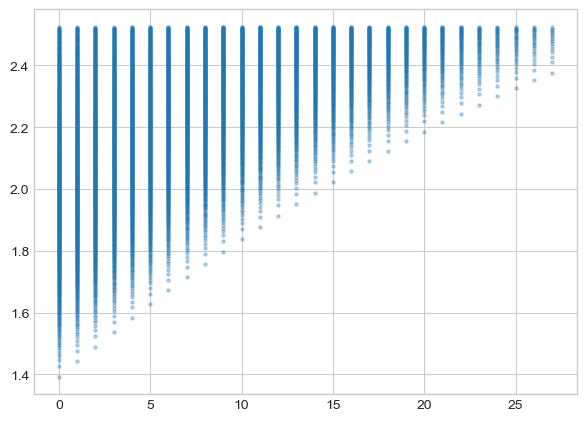

In [7]:
x = model_baseline.sol.age[:, 31][model_baseline.sol.l_h[:, 31] == 0]
y = model_baseline.sol.theta_h[:, 31][model_baseline.sol.l_h[:, 31] == 0]
# x = model_baseline.sol.wage[:, 31][model_baseline.sol.l_h[:, 31] == 1]


plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=5, alpha=0.3)

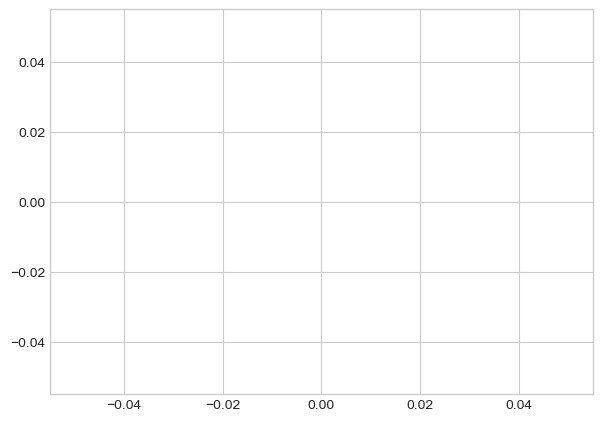

In [8]:
x = model_baseline.sol.age[:, 31][model_baseline.sol.l_h[:, 31] == 1]
y = model_baseline.sol.theta_h[:, 31][model_baseline.sol.l_h[:, 31] == 1]
# x = model_baseline.sol.wage[:, 31][model_baseline.sol.l_h[:, 31] == 1]


plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=5, alpha=0.3)

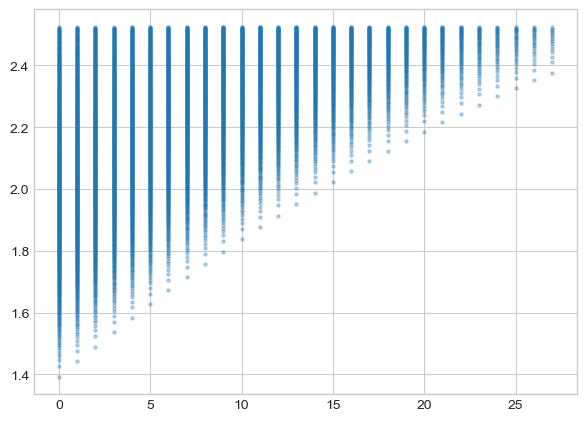

In [9]:
x = model_baseline.sol.age[:, 31][model_baseline.sol.l_h[:, 31] == 0]
y = model_baseline.sol.theta_h[:, 31][model_baseline.sol.l_h[:, 31] == 0]
# x = model_baseline.sol.wage[:, 31][model_baseline.sol.l_h[:, 31] == 1]


plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=5, alpha=0.3)